# §2 · Efficient Frontier & Capital Market Line
**Bachelorarbeit: Kritik des CAPM und Erweiterung durch das Black-Litterman-Modell**  
Lucas Posern · TU Dresden · 2026

> LaTeX: `Definitionen.tex`

Dieses Notebook reproduziert die Efficient-Frontier-Abbildung aus §2.  
Läuft vollständig offline, ohne Internetzugang.

**Parameter:**
$$\mu = (0.08, 0.13, 0.18), \quad \Sigma = \begin{pmatrix} 0.04 & 0.01 & 0.005 \\ 0.01 & 0.09 & 0.02 \\ 0.005 & 0.02 & 0.16 \end{pmatrix}, \quad r_f = 0.03$$

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# core/ auf sys.path
ROOT = Path(os.path.abspath(''))   # = Thesis_code_abgabe/
CORE = ROOT / 'core'
DATA = ROOT / 'data'
if str(CORE) not in sys.path:
    sys.path.insert(0, str(CORE))

# Thesis-Module
from data_loader import load_idzorek_etf, load_local_idzorek, IDZOREK_LABELS, IDZOREK_W_EQ

# Plot-Stil
plt.rcParams.update({
    'figure.dpi': 130, 'figure.figsize': (9, 4.5),
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'lines.linewidth': 1.8,
})
C = ['#1f4e79', '#c00000', '#538135', '#7030a0', '#833c00', '#005073']
from IPython.display import display
print('Setup abgeschlossen.')

Setup abgeschlossen.


---
## §2.2 / §2.3 · Mean-Variance-Frontier & Capital Market Line

MVP      : mu = 0.1042,  sigma = 0.1697
Tangency : mu = 0.1273,  sigma = 0.1944,  Sharpe = 0.5006


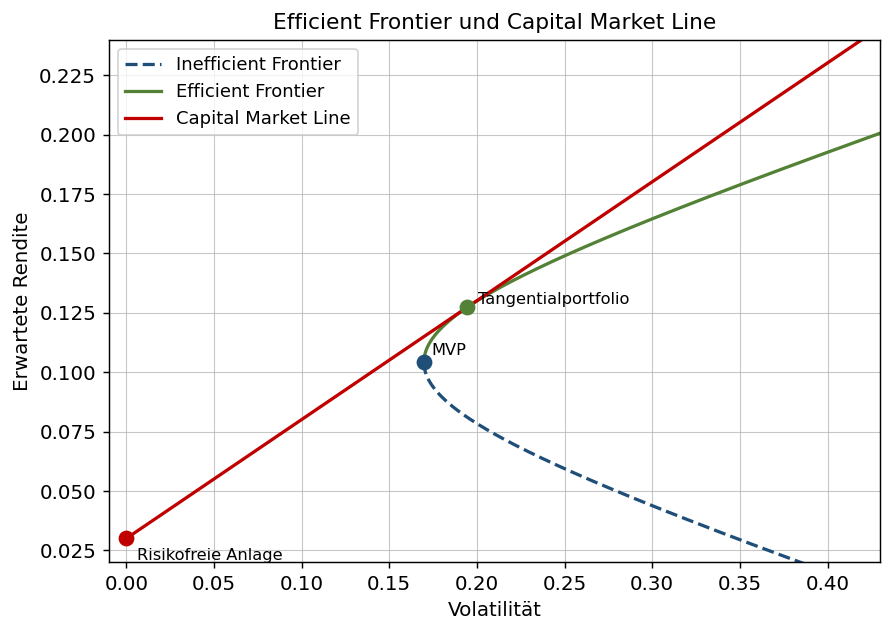

In [2]:
%matplotlib inline
from IPython.display import display

# Parameter
mu_3    = np.array([0.08, 0.13, 0.18])
Sigma_3 = np.array([[0.040, 0.010, 0.005],
                    [0.010, 0.090, 0.020],
                    [0.005, 0.020, 0.160]])
rf_3    = 0.03
ones3   = np.ones(3)

# Analytische Hilfsgroessen (Two-Fund-Separation)
S_inv = np.linalg.inv(Sigma_3)
a3 = mu_3  @ S_inv @ mu_3
b3 = ones3 @ S_inv @ mu_3
c3 = ones3 @ S_inv @ ones3
d3 = a3 * c3 - b3 ** 2

def frontier_vol(mu_target):
    return np.sqrt((c3 * mu_target**2 - 2*b3 * mu_target + a3) / d3)

# Minimum-Variance-Portfolio (MVP)
w_mvp   = S_inv @ ones3 / c3
mu_mvp  = w_mvp @ mu_3
sig_mvp = np.sqrt(w_mvp @ Sigma_3 @ w_mvp)

# Tangentialportfolio (Sharpe-optimal)
z3      = S_inv @ (mu_3 - rf_3)
w_tan   = z3 / z3.sum()
mu_tan  = w_tan @ mu_3
sig_tan = np.sqrt(w_tan @ Sigma_3 @ w_tan)
sharpe_T = (mu_tan - rf_3) / sig_tan

print(f'MVP      : mu = {mu_mvp:.4f},  sigma = {sig_mvp:.4f}')
print(f'Tangency : mu = {mu_tan:.4f},  sigma = {sig_tan:.4f},  Sharpe = {sharpe_T:.4f}')

# Frontier-Kurven
mu_eff  = np.linspace(mu_mvp, 0.235, 400)
mu_inef = np.linspace(mu_mvp, -0.04, 200)
sig_cml = np.linspace(0, 0.42, 300)
mu_cml  = rf_3 + sharpe_T * sig_cml

# Abbildung
fig, ax = plt.subplots(figsize=(7, 5))
for sp in ax.spines.values():
    sp.set_visible(True)
ax.grid(True, linewidth=0.6, alpha=0.7)

ax.plot(frontier_vol(mu_inef), mu_inef, color=C[0], ls='--', lw=1.8, label='Inefficient Frontier')
ax.plot(frontier_vol(mu_eff),  mu_eff,  color=C[2], ls='-',  lw=1.8, label='Efficient Frontier')
ax.plot(sig_cml, mu_cml,               color=C[1], ls='-',  lw=1.8, label='Capital Market Line')

ax.scatter(0,        rf_3,    s=60, color=C[1], zorder=5)
ax.scatter(sig_mvp,  mu_mvp,  s=60, color=C[0], zorder=5)
ax.scatter(sig_tan,  mu_tan,  s=60, color=C[2], zorder=5)

ax.annotate('Risikofreie Anlage', (0, rf_3),         textcoords='offset points', xytext=(6, -12), fontsize=9)
ax.annotate('MVP',       (sig_mvp, mu_mvp), textcoords='offset points', xytext=(4,  4),  fontsize=9)
ax.annotate('Tangentialportfolio', (sig_tan, mu_tan), textcoords='offset points', xytext=(6,  2),  fontsize=9)

ax.set_xlabel('Volatilität')
ax.set_ylabel('Erwartete Rendite')
ax.set_title('Efficient Frontier und Capital Market Line')
ax.set_xlim(-0.01, 0.43)
ax.set_ylim(0.020, 0.240)
ax.legend(loc='upper left')
plt.tight_layout()
display(fig)
plt.close(fig)